开始生成数据可视化图表...
共找到 167 次刷新事件, 109 次购买事件

1. 生成刷新分布散点图...


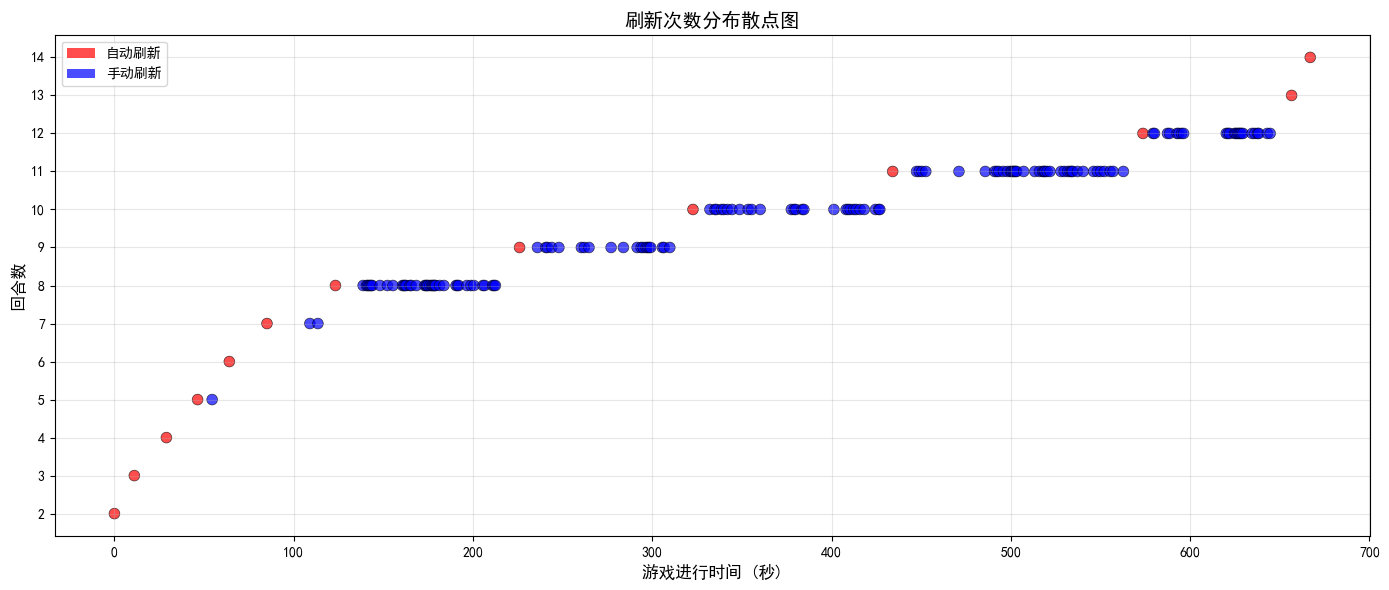


2. 生成虎符消耗散点图...


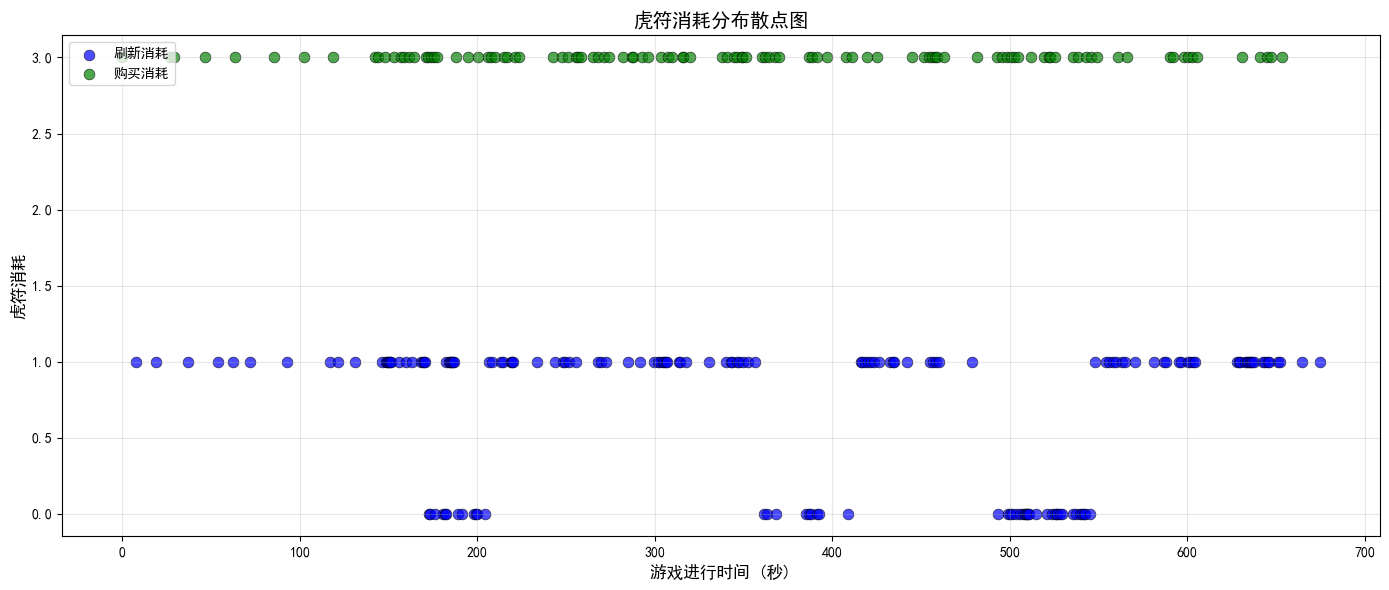


3. 生成回合统计柱状图...


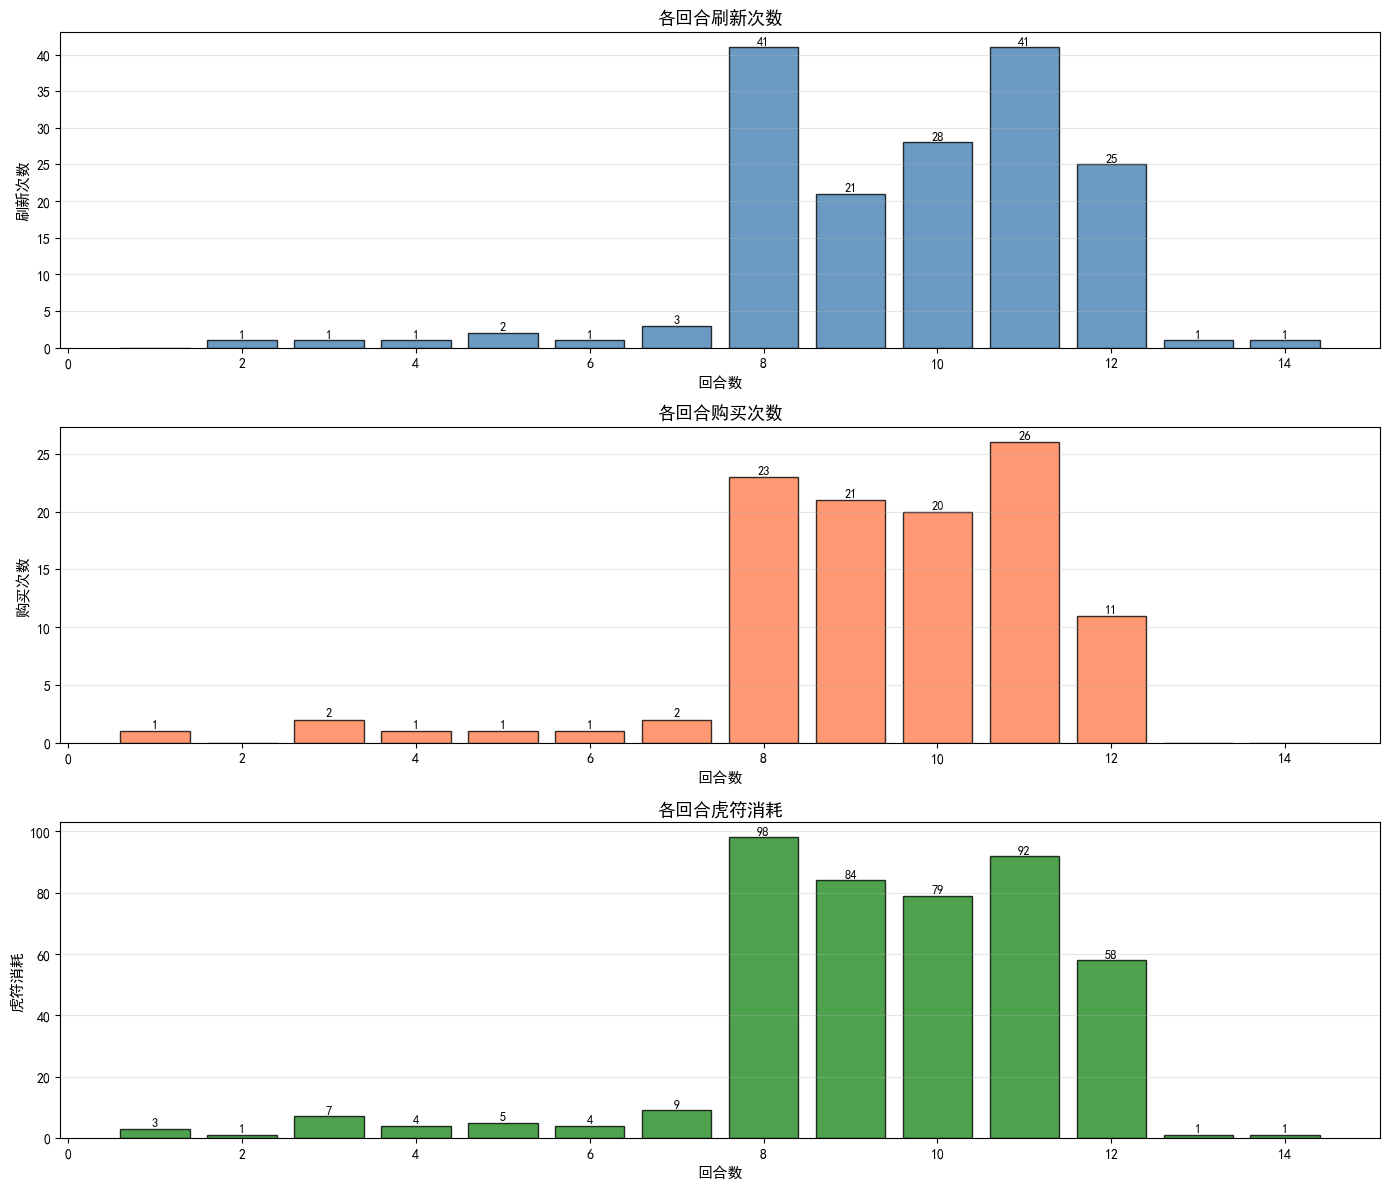


4. 生成卡牌出现排行...


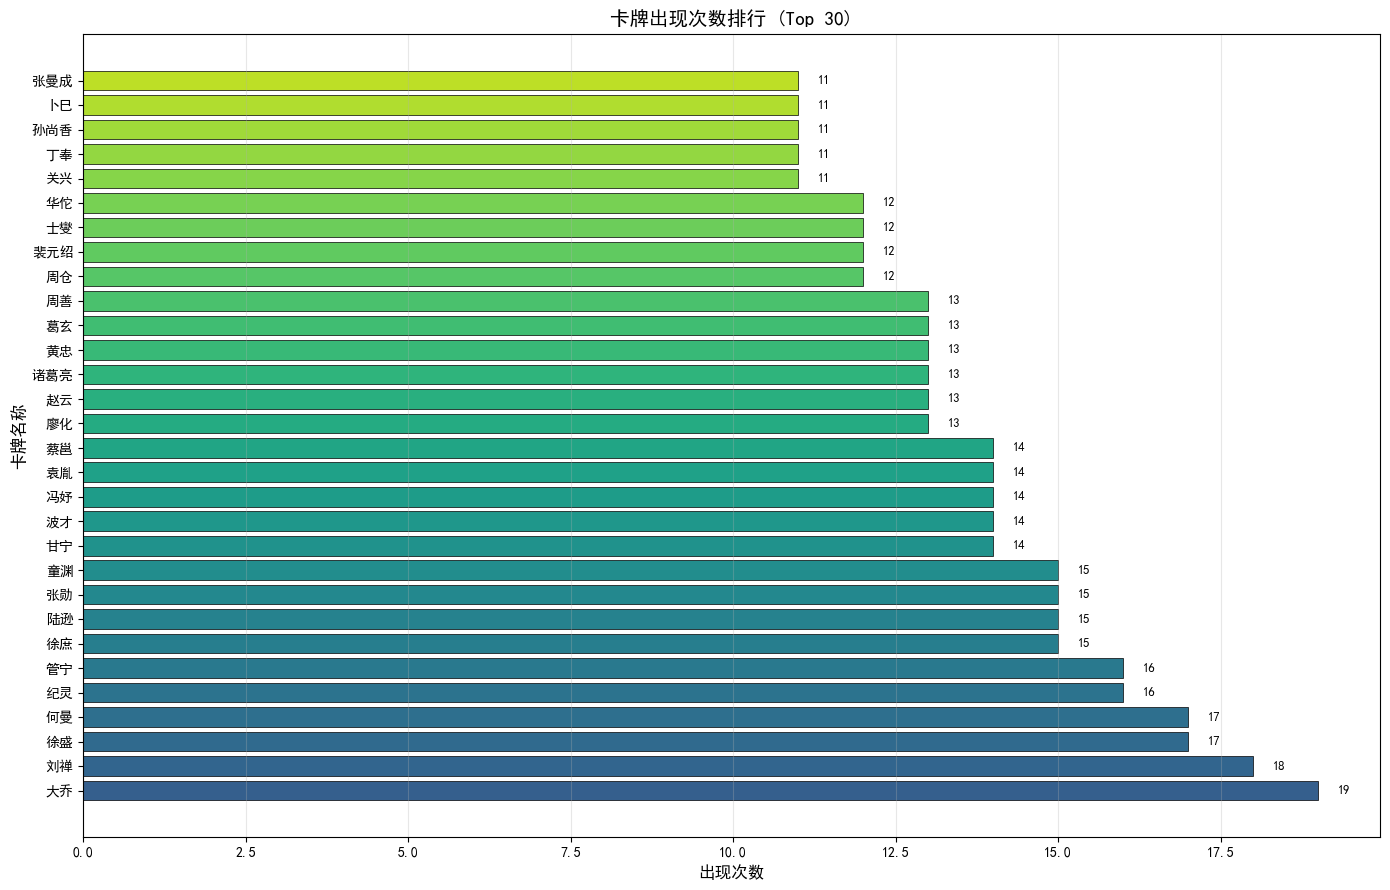


=== 卡牌出现次数排行 (Top 20) ===
  1. 大乔: 19 次
  2. 刘禅: 18 次
  3. 徐盛: 17 次
  4. 何曼: 17 次
  5. 纪灵: 16 次
  6. 管宁: 16 次
  7. 徐庶: 15 次
  8. 陆逊: 15 次
  9. 张勋: 15 次
 10. 童渊: 15 次
 11. 甘宁: 14 次
 12. 波才: 14 次
 13. 冯妤: 14 次
 14. 袁胤: 14 次
 15. 蔡邕: 14 次
 16. 廖化: 13 次
 17. 赵云: 13 次
 18. 诸葛亮: 13 次
 19. 黄忠: 13 次
 20. 葛玄: 13 次

5. 生成锦囊出现排行...


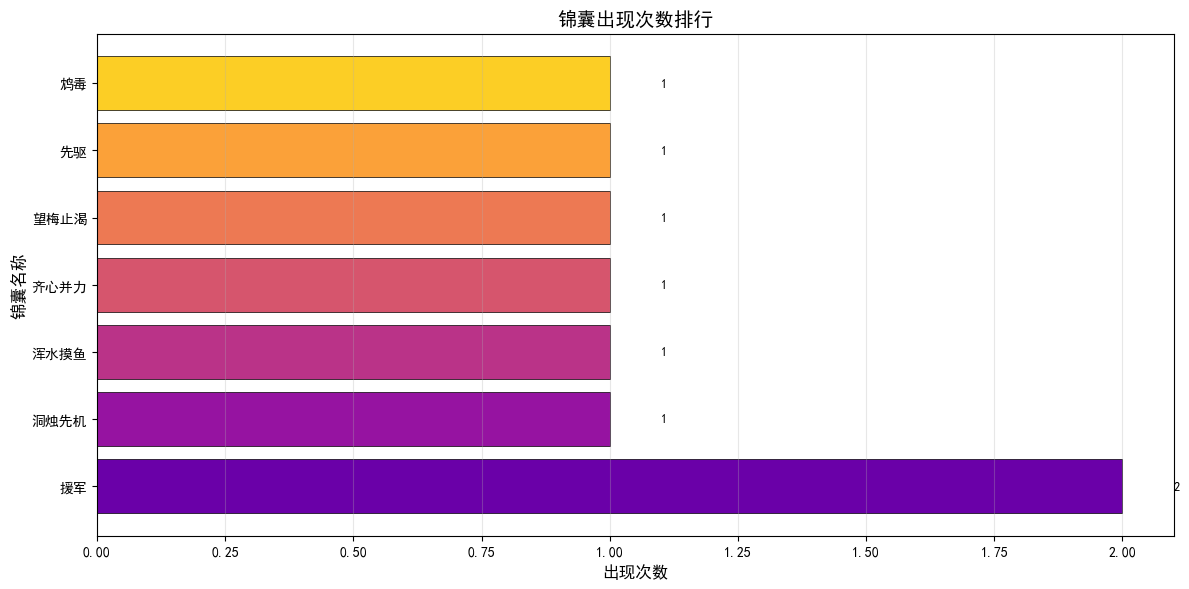


=== 锦囊出现次数排行 ===
  1. 援军: 2 次
  2. 洞烛先机: 1 次
  3. 浑水摸鱼: 1 次
  4. 齐心并力: 1 次
  5. 望梅止渴: 1 次
  6. 先驱: 1 次
  7. 鸩毒: 1 次

6. 生成各回合卡牌种类数图...


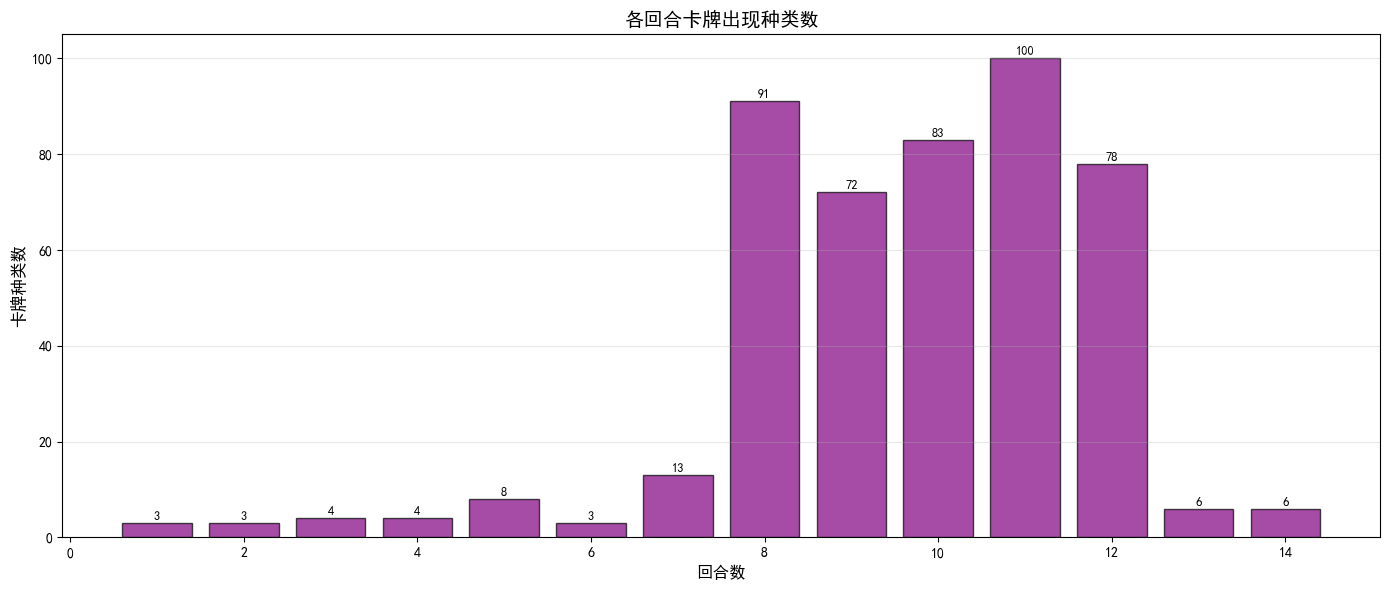


7. 生成购买卡牌排行...


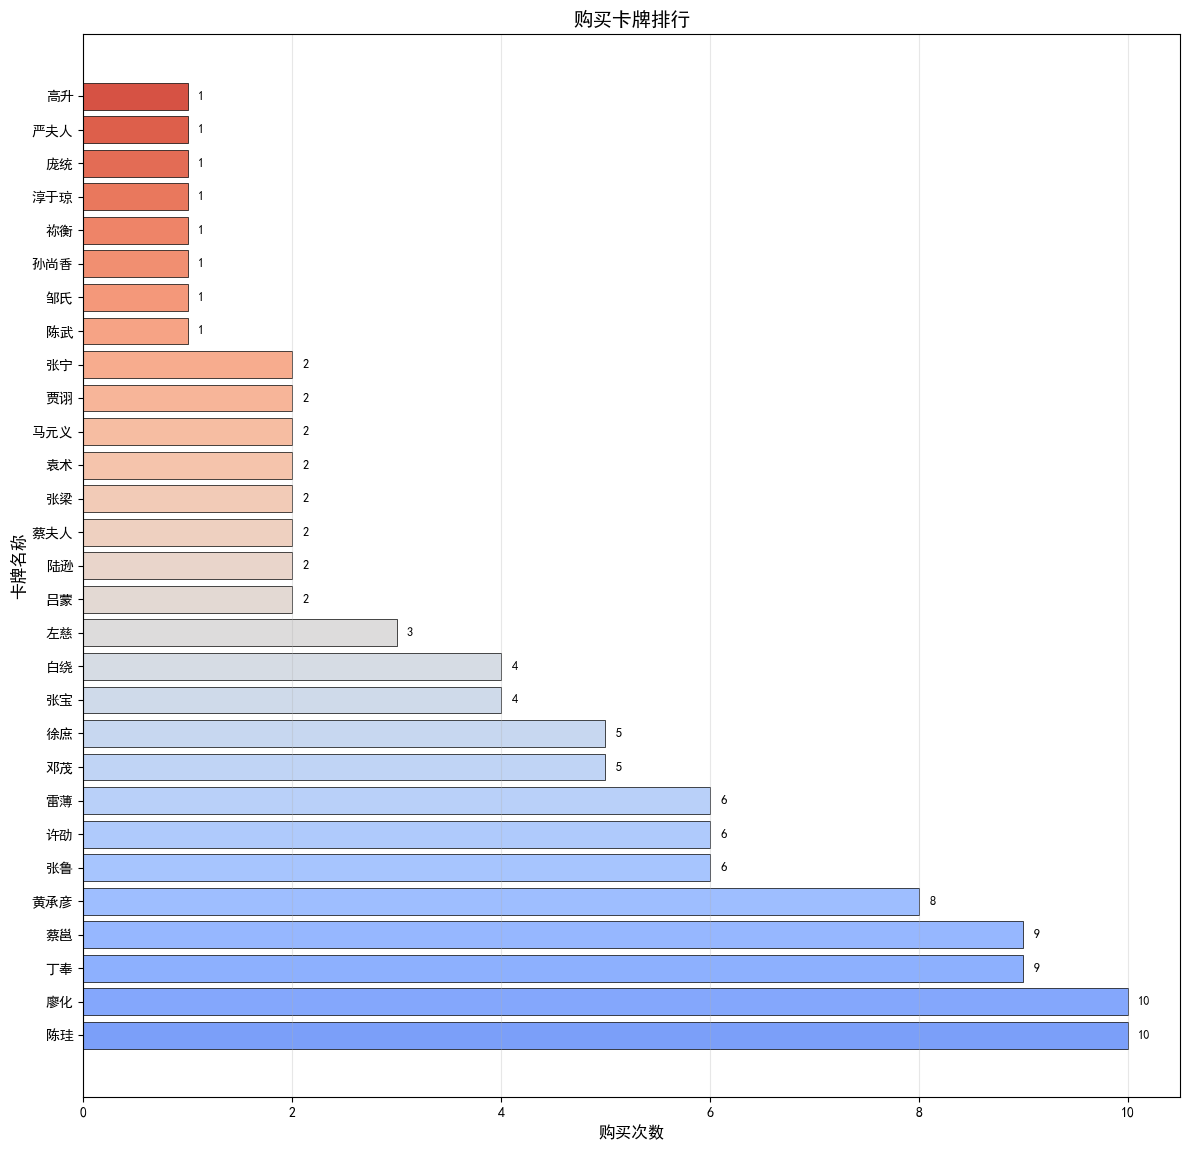


=== 购买卡牌排行 ===
  1. 陈珪: 10 次
  2. 廖化: 10 次
  3. 丁奉: 9 次
  4. 蔡邕: 9 次
  5. 黄承彦: 8 次
  6. 张鲁: 6 次
  7. 许劭: 6 次
  8. 雷薄: 6 次
  9. 邓茂: 5 次
 10. 徐庶: 5 次
 11. 张宝: 4 次
 12. 白绕: 4 次
 13. 左慈: 3 次
 14. 吕蒙: 2 次
 15. 陆逊: 2 次
 16. 蔡夫人: 2 次
 17. 张梁: 2 次
 18. 袁术: 2 次
 19. 马元义: 2 次
 20. 贾诩: 2 次
 21. 张宁: 2 次
 22. 陈武: 1 次
 23. 邹氏: 1 次
 24. 孙尚香: 1 次
 25. 祢衡: 1 次
 26. 淳于琼: 1 次
 27. 庞统: 1 次
 28. 严夫人: 1 次
 29. 高升: 1 次

8. 生成统计摘要...


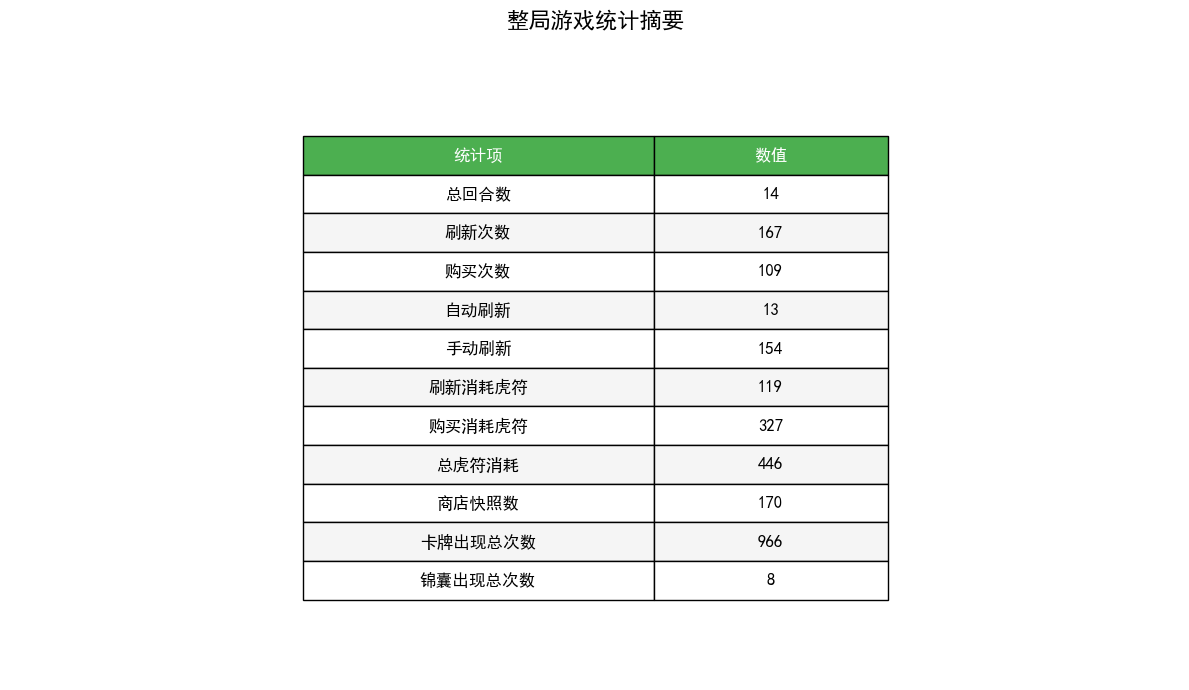


所有图表生成完成！


In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 读取JSON数据
with open('log.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# ============ 从 events 中提取刷新和购买事件 ============
def extract_refresh_and_buy_events(data):
    """从 events 中提取刷新和购买事件"""
    refresh_events = []
    buy_events = []
    
    for event in data.get('events', []):
        if event['type'] == 'refresh':
            payload = event.get('payload', {})
            refresh_events.append({
                'at': event['at'],
                'round': payload.get('round', 'unknown'),
                'cost': payload.get('cost', 0),
                'is_auto': payload.get('isAuto', False)
            })
        elif event['type'] == 'buy':
            payload = event.get('payload', {})
            goods = payload.get('goods', {})
            buy_events.append({
                'at': event['at'],
                'round': payload.get('round', 'unknown'),
                'cost': payload.get('cost', 0),
                'goods_name': goods.get('name', 'unknown'),
                'goods_id': goods.get('chessID', 0)
            })
    
    return refresh_events, buy_events

refresh_events, buy_events = extract_refresh_and_buy_events(data)

# ============ 1. 整局游戏刷新次数关于时间戳的分布散点图 ============
def plot_refresh_distribution(refresh_events):
    """绘制刷新次数关于时间戳的分布散点图"""
    if not refresh_events:
        print("没有刷新事件数据")
        return None
    
    df = pd.DataFrame(refresh_events)
    df['round'] = df['round'].astype(int)
    df['datetime'] = pd.to_datetime(df['at'])
    df['time_seconds'] = (df['datetime'] - df['datetime'].min()).dt.total_seconds()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # 按是否自动刷新区分颜色
    colors = ['red' if is_auto else 'blue' for is_auto in df['is_auto']]
    
    scatter = ax.scatter(df['time_seconds'], df['round'], 
                         c=colors, s=60, alpha=0.7, 
                         edgecolors='black', linewidth=0.5)
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.7, label='自动刷新'),
        Patch(facecolor='blue', alpha=0.7, label='手动刷新')
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    
    ax.set_xlabel('游戏进行时间 (秒)', fontsize=12)
    ax.set_ylabel('回合数', fontsize=12)
    ax.set_title('刷新次数分布散点图', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    ax.set_yticks(sorted(df['round'].unique()))
    
    plt.tight_layout()
    plt.savefig('refresh_distribution.png', dpi=150)
    plt.show()
    return df

# ============ 2. 整局游戏虎符消耗关于时间戳的分布散点图 ============
def plot_cost_distribution(refresh_events, buy_events):
    """绘制虎符消耗关于时间戳的分布散点图"""
    cost_events = []
    
    for r in refresh_events:
        cost_events.append({
            'at': r['at'],
            'round': int(r['round']),
            'cost': r['cost'],
            'type': '刷新'
        })
    
    for b in buy_events:
        cost_events.append({
            'at': b['at'],
            'round': int(b['round']),
            'cost': b['cost'],
            'type': '购买'
        })
    
    if not cost_events:
        print("没有消耗事件数据")
        return None
    
    df = pd.DataFrame(cost_events)
    df['datetime'] = pd.to_datetime(df['at'])
    df['time_seconds'] = (df['datetime'] - df['datetime'].min()).dt.total_seconds()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    refresh_df = df[df['type'] == '刷新']
    buy_df = df[df['type'] == '购买']
    
    if not refresh_df.empty:
        ax.scatter(refresh_df['time_seconds'], refresh_df['cost'], 
                   c='blue', s=60, alpha=0.7, label='刷新消耗', 
                   edgecolors='black', linewidth=0.5)
    if not buy_df.empty:
        ax.scatter(buy_df['time_seconds'], buy_df['cost'], 
                   c='green', s=60, alpha=0.7, label='购买消耗', 
                   edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('游戏进行时间 (秒)', fontsize=12)
    ax.set_ylabel('虎符消耗', fontsize=12)
    ax.set_title('虎符消耗分布散点图', fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('cost_distribution.png', dpi=150)
    plt.show()
    return df

# ============ 3. 每个回合的刷新次数/购买次数/虎符消耗（柱状图） ============
def plot_round_stats(refresh_events, buy_events):
    """绘制每个回合的统计柱状图"""
    # 获取所有回合
    all_rounds = sorted(set([int(r['round']) for r in refresh_events] + 
                           [int(b['round']) for b in buy_events] + 
                           [int(k) for k in data['rounds'].keys()]))
    
    round_stats = []
    for r in all_rounds:
        r_refreshes = [e for e in refresh_events if int(e['round']) == r]
        r_buys = [e for e in buy_events if int(e['round']) == r]
        total_cost = sum(e['cost'] for e in r_refreshes) + sum(e['cost'] for e in r_buys)
        
        round_stats.append({
            'round': r,
            'refresh_count': len(r_refreshes),
            'buy_count': len(r_buys),
            'total_cost': total_cost
        })
    
    df = pd.DataFrame(round_stats).sort_values('round')
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # 刷新次数
    axes[0].bar(df['round'], df['refresh_count'], color='steelblue', alpha=0.8, edgecolor='black')
    axes[0].set_xlabel('回合数', fontsize=11)
    axes[0].set_ylabel('刷新次数', fontsize=11)
    axes[0].set_title('各回合刷新次数', fontsize=13)
    axes[0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(df['refresh_count']):
        if v > 0:
            axes[0].text(df['round'].iloc[i], v + 0.1, str(v), ha='center', va='bottom', fontsize=9)
    
    # 购买次数
    axes[1].bar(df['round'], df['buy_count'], color='coral', alpha=0.8, edgecolor='black')
    axes[1].set_xlabel('回合数', fontsize=11)
    axes[1].set_ylabel('购买次数', fontsize=11)
    axes[1].set_title('各回合购买次数', fontsize=13)
    axes[1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(df['buy_count']):
        if v > 0:
            axes[1].text(df['round'].iloc[i], v + 0.1, str(v), ha='center', va='bottom', fontsize=9)
    
    # 虎符消耗
    axes[2].bar(df['round'], df['total_cost'], color='forestgreen', alpha=0.8, edgecolor='black')
    axes[2].set_xlabel('回合数', fontsize=11)
    axes[2].set_ylabel('虎符消耗', fontsize=11)
    axes[2].set_title('各回合虎符消耗', fontsize=13)
    axes[2].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(df['total_cost']):
        if v > 0:
            axes[2].text(df['round'].iloc[i], v + 0.1, str(v), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('round_stats.png', dpi=150)
    plt.show()
    return df

# ============ 4. 整局游戏各chess（卡牌）出现的次数（从高到低） ============
def plot_chess_appearances(data, top_n=30):
    """绘制卡牌出现次数排行"""
    if not data.get('shopAppearances'):
        print("没有卡牌出现数据")
        return None
    
    chess_appearances = {}
    for key, value in data['shopAppearances'].items():
        if key != 'unknown' and not key.startswith('spell:'):
            name = value['sample'].get('name', key)
            chess_appearances[name] = value['count']
    
    sorted_items = sorted(chess_appearances.items(), key=lambda x: x[1], reverse=True)
    
    if not sorted_items:
        print("没有卡牌数据")
        return None
    
    top_items = sorted_items[:top_n]
    names, counts = zip(*top_items)
    
    fig, ax = plt.subplots(figsize=(14, max(8, len(top_items) * 0.3)))
    
    bars = ax.barh(names, counts, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(names))), 
                   edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('出现次数', fontsize=12)
    ax.set_ylabel('卡牌名称', fontsize=12)
    ax.set_title(f'卡牌出现次数排行 (Top {len(top_items)})', fontsize=14)
    ax.grid(True, alpha=0.3, axis='x')
    
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
                str(count), va='center', ha='left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('chess_appearances.png', dpi=150)
    plt.show()
    
    print("\n=== 卡牌出现次数排行 (Top 20) ===")
    for i, (name, count) in enumerate(sorted_items[:20], 1):
        print(f"{i:3d}. {name}: {count} 次")
    
    return sorted_items

# ============ 5. 整局游戏各spell（锦囊）出现的次数（从高到低） ============
def plot_spell_appearances(data):
    """绘制锦囊出现次数排行"""
    if not data.get('spells'):
        print("没有锦囊数据")
        return None
    
    spell_items = []
    for key, value in data['spells'].items():
        name = value['sample'].get('name', key)
        spell_items.append((name, value['count']))
    
    sorted_items = sorted(spell_items, key=lambda x: x[1], reverse=True)
    
    if not sorted_items:
        print("没有锦囊数据")
        return None
    
    names, counts = zip(*sorted_items)
    
    fig, ax = plt.subplots(figsize=(12, max(6, len(names) * 0.4)))
    
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(names)))
    bars = ax.barh(names, counts, color=colors, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('出现次数', fontsize=12)
    ax.set_ylabel('锦囊名称', fontsize=12)
    ax.set_title('锦囊出现次数排行', fontsize=14)
    ax.grid(True, alpha=0.3, axis='x')
    
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                str(count), va='center', ha='left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('spell_appearances.png', dpi=150)
    plt.show()
    
    print("\n=== 锦囊出现次数排行 ===")
    for i, (name, count) in enumerate(sorted_items, 1):
        print(f"{i:3d}. {name}: {count} 次")
    
    return sorted_items

# ============ 额外图表：各回合卡牌出现种类数 ============
def plot_round_card_diversity(data):
    """绘制各回合卡牌出现种类数"""
    round_diversity = []
    for round_key, round_data in data['rounds'].items():
        cards = set()
        for key in round_data['shop']['appearances'].keys():
            if key != 'unknown' and not key.startswith('spell:'):
                cards.add(key)
        round_diversity.append({
            'round': int(round_key),
            'diversity': len(cards)
        })
    
    df = pd.DataFrame(round_diversity).sort_values('round')
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(df['round'], df['diversity'], color='purple', alpha=0.7, edgecolor='black')
    ax.set_xlabel('回合数', fontsize=12)
    ax.set_ylabel('卡牌种类数', fontsize=12)
    ax.set_title('各回合卡牌出现种类数', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(df['diversity']):
        ax.text(df['round'].iloc[i], v + 0.2, str(v), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('round_card_diversity.png', dpi=150)
    plt.show()
    return df

# ============ 额外图表：购买卡牌排行 ============
def plot_bought_chess_ranking(buy_events):
    """绘制购买卡牌排行"""
    if not buy_events:
        print("没有购买事件数据")
        return None
    
    bought_count = {}
    for b in buy_events:
        name = b.get('goods_name', 'unknown')
        if name != 'unknown':
            bought_count[name] = bought_count.get(name, 0) + 1
    
    sorted_items = sorted(bought_count.items(), key=lambda x: x[1], reverse=True)
    
    if not sorted_items:
        print("没有购买卡牌数据")
        return None
    
    names, counts = zip(*sorted_items)
    
    fig, ax = plt.subplots(figsize=(12, max(6, len(names) * 0.4)))
    
    colors = plt.cm.coolwarm(np.linspace(0.2, 0.9, len(names)))
    bars = ax.barh(names, counts, color=colors, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('购买次数', fontsize=12)
    ax.set_ylabel('卡牌名称', fontsize=12)
    ax.set_title('购买卡牌排行', fontsize=14)
    ax.grid(True, alpha=0.3, axis='x')
    
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                str(count), va='center', ha='left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('bought_chess_ranking.png', dpi=150)
    plt.show()
    
    print("\n=== 购买卡牌排行 ===")
    for i, (name, count) in enumerate(sorted_items, 1):
        print(f"{i:3d}. {name}: {count} 次")
    
    return sorted_items

# ============ 额外图表：统计摘要 ============
def plot_summary_stats(data, refresh_events, buy_events):
    """绘制整局统计摘要"""
    total_rounds = len(data['rounds'])
    total_refresh = len(refresh_events)
    total_buy = len(buy_events)
    total_hufu_refresh = sum(e['cost'] for e in refresh_events)
    total_hufu_buy = sum(e['cost'] for e in buy_events)
    total_hufu = total_hufu_refresh + total_hufu_buy
    total_snapshots = data['totals']['shop']['snapshots']
    
    total_chess = sum(v['count'] for k, v in data['shopAppearances'].items() 
                     if k != 'unknown' and not k.startswith('spell:'))
    total_spells = sum(v['count'] for v in data['spells'].values())
    
    # 计算自动刷新次数
    auto_refresh = sum(1 for e in refresh_events if e.get('is_auto', False))
    
    stats = {
        '总回合数': total_rounds,
        '刷新次数': total_refresh,
        '购买次数': total_buy,
        '自动刷新': auto_refresh,
        '手动刷新': total_refresh - auto_refresh,
        '刷新消耗虎符': total_hufu_refresh,
        '购买消耗虎符': total_hufu_buy,
        '总虎符消耗': total_hufu,
        '商店快照数': total_snapshots,
        '卡牌出现总次数': total_chess,
        '锦囊出现总次数': total_spells
    }
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.axis('off')
    
    table_data = []
    for key, value in stats.items():
        table_data.append([key, str(value)])
    
    table = ax.table(cellText=table_data, colLabels=['统计项', '数值'], 
                     cellLoc='center', loc='center',
                     colWidths=[0.3, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    
    for i in range(2):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    for i in range(1, len(table_data) + 1):
        if i % 2 == 0:
            for j in range(2):
                table[(i, j)].set_facecolor('#f5f5f5')
    
    ax.set_title('整局游戏统计摘要', fontsize=16, pad=20)
    
    plt.tight_layout()
    plt.savefig('summary_stats.png', dpi=150)
    plt.show()
    
    return stats

# ============ 执行所有绘图 ============
if __name__ == "__main__":
    print("开始生成数据可视化图表...")
    print("=" * 50)
    print(f"共找到 {len(refresh_events)} 次刷新事件, {len(buy_events)} 次购买事件")
    
    # 1. 刷新分布散点图
    print("\n1. 生成刷新分布散点图...")
    refresh_df = plot_refresh_distribution(refresh_events)
    
    # 2. 虎符消耗散点图
    print("\n2. 生成虎符消耗散点图...")
    cost_df = plot_cost_distribution(refresh_events, buy_events)
    
    # 3. 回合统计柱状图
    print("\n3. 生成回合统计柱状图...")
    round_df = plot_round_stats(refresh_events, buy_events)
    
    # 4. 卡牌出现排行
    print("\n4. 生成卡牌出现排行...")
    chess_rank = plot_chess_appearances(data, top_n=30)
    
    # 5. 锦囊出现排行
    print("\n5. 生成锦囊出现排行...")
    spell_rank = plot_spell_appearances(data)
    
    # 6. 各回合卡牌种类数
    print("\n6. 生成各回合卡牌种类数图...")
    diversity_df = plot_round_card_diversity(data)
    
    # 7. 购买卡牌排行
    print("\n7. 生成购买卡牌排行...")
    bought_rank = plot_bought_chess_ranking(buy_events)
    
    # 8. 统计摘要
    print("\n8. 生成统计摘要...")
    summary = plot_summary_stats(data, refresh_events, buy_events)
    
    print("\n" + "=" * 50)
    print("所有图表生成完成！")

In [2]:
total_hufu

NameError: name 'total_hufu' is not defined